This notebook just takes the output csv and .npy files generated during training and visualizes the results. It does not run inference

In [1]:
# In your first cell, turn on the ipympl interactive backend:
%matplotlib widget
import matplotlib.pyplot as plt

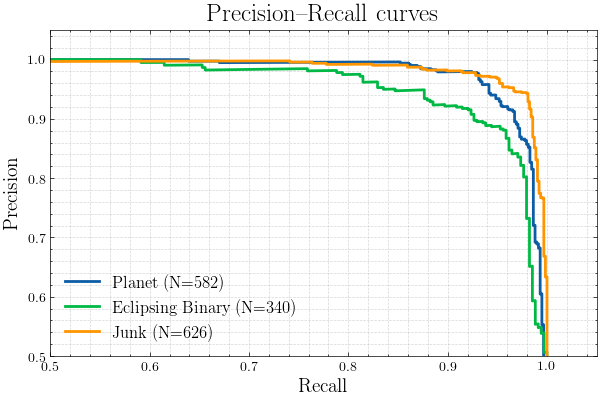

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
)
import scienceplots

plt.style.use('science')
# If you want widget‐based clicks in a Jupyter environment, uncomment:
# %matplotlib widget

# ─── 0) load & preprocess ────────────────────────────────────────────────
training_run_folder = "/pdo/users/pablomer/mnt/tess/models/vetting/20250502/" \
                      "cshallue/AstroCNNModelVetting_cshallue_20250502_000812"
test_labels = np.load(f"{training_run_folder}/evaluation/test_label.npy")  # (1548,4)
test_pred   = np.load(f"{training_run_folder}/evaluation/test_pred.npy")

# drop the “Not Sure” column
test_labels = np.delete(test_labels, 2, axis=1)
test_pred   = np.delete(test_pred,   2, axis=1)

label_names = ["Planet", "Eclipsing Binary", "Junk"]
counts = test_labels.sum(axis=0).astype(int)

# ─── 1) compute PR for each class ────────────────────────────────────────
pr_data = []
for i in range(len(label_names)):
    y_true  = test_labels[:, i]
    y_score = test_pred[:,   i]
    p, r, t  = precision_recall_curve(y_true, y_score)
    ap       = average_precision_score(y_true, y_score)
    pr_data.append({
        "precision": p,
        "recall":    r,
        "thresholds":t,
        "ap":        ap
    })

# ─── 2) plot all three curves ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)

lines = []
for i, name in enumerate(label_names):
    data = pr_data[i]
    lbl  = f"{name} (N={counts[i]})"
    ln, = ax.plot(data["recall"][:-1],
                  data["precision"][:-1],
                  lw=2, label=lbl)
    lines.append(ln)

ax.set_xlabel("Recall",    fontsize=14)
ax.set_ylabel("Precision", fontsize=14)
ax.set_title("Precision–Recall curves", fontsize=18)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.5, 1.05)

# ─── 3) add interactive annotation ───────────────────────────────────────
annot = ax.annotate(
    "",
    xy=(0,0), xytext=(-40,-20),
    textcoords="offset points",
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.5", fc="w", alpha=0.9, clip_on=False),
    arrowprops=dict(arrowstyle="->")
)
annot.set_visible(False)

def update_annot(class_idx, ind):
    idx = ind["ind"][0]
    d   = pr_data[class_idx]
    annot.xy = (d["recall"][idx], d["precision"][idx])
    annot.set_text(
        f"{label_names[class_idx]}\n"
        f"Precision = {d['precision'][idx]:.3f}\n"
        f"Recall = {d['recall'][idx]:.3f}\n"
        f"Threshold = {d['thresholds'][idx]:.3f}"
    )

def onclick(event):
    if event.inaxes != ax:
        return
    for i, ln in enumerate(lines):
        hit, ind = ln.contains(event)
        if hit:
            update_annot(i, ind)
            annot.set_visible(True)
            fig.canvas.draw_idle()
            return
    # click elsewhere hides the box
    if annot.get_visible():
        annot.set_visible(False)
        fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", onclick)

# ─── 4) legend & show ───────────────────────────────────────────────────
ax.legend(loc="lower left", fontsize=12, framealpha=0.8)
plt.show()

# ─── 5) extra diagnostics (optional) ────────────────────────────────────
# You can still compute confusion matrices, ROC, etc., exactly as before.


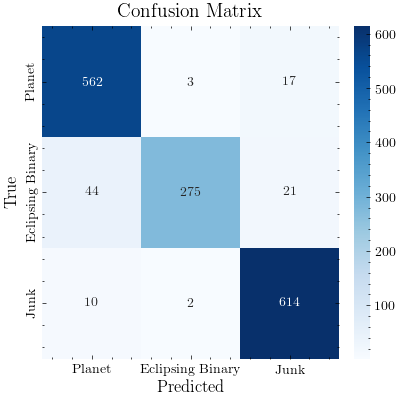

,precision,recall,f1-score,support
Planet,0.912000,0.966000,0.938000,582.000000
Eclipsing Binary,0.982000,0.809000,0.887000,340.000000
Junk,0.942000,0.981000,0.961000,626.000000
accuracy,0.937000,0.937000,0.937000,0.937000
macro avg,0.945000,0.918000,0.929000,1548.000000
weighted avg,0.940000,0.937000,0.936000,1548.000000


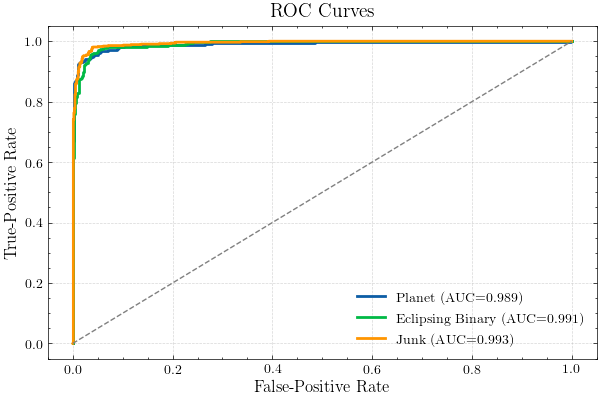

In [3]:
# ─── Cell 2: More Diagnostics ─────────────────────────────────────────────

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)

# 1) Confusion matrix heatmap
y_true = test_labels.argmax(axis=1)
y_pred = test_pred.argmax(axis=1)



cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True",      fontsize=12)
ax.set_title("Confusion Matrix", fontsize=14)
plt.show()

# 2) Styled classification report
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    output_dict=True
)
df_report = pd.DataFrame(report_dict).T.round(3)

# pick only the float‐valued metric columns
num_cols = df_report.select_dtypes(include=['float']).columns

styled = (
    df_report.style
      .background_gradient(cmap="Blues", subset=pd.IndexSlice[:, num_cols])
      .set_caption("Classification Report")
)
display(styled)

# 3) ROC curves + AUC
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)
for i, name in enumerate(label_names):
    fpr, tpr, _ = roc_curve(test_labels[:, i], test_pred[:, i])
    auc = roc_auc_score(test_labels[:, i], test_pred[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0,1], [0,1], "--", color="gray", lw=1)
ax.set_xlabel("False-Positive Rate", fontsize=12)
ax.set_ylabel("True-Positive Rate",  fontsize=12)
ax.set_title("ROC Curves",            fontsize=14)
ax.legend(loc="lower right", fontsize=10, framealpha=0.8)
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()


---

## Prediction Visualizer for the case of cross-validation

In [4]:
# In your first cell, turn on the ipympl interactive backend:
%matplotlib widget

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
)
import scienceplots

# 0 - Load and preprocess
# crossval_training_run_folder = "/pdo/users/pablomer/mnt/tess/models/vetting/20250520-1546/cshallue-cv"
crossval_training_run_folder = "/pdo/users/pablomer/mnt/tess/models/vetting/20250522-1615/pablomer-cv"
number_of_folds = 2

for i in range(number_of_folds):
    print(i)


0
1


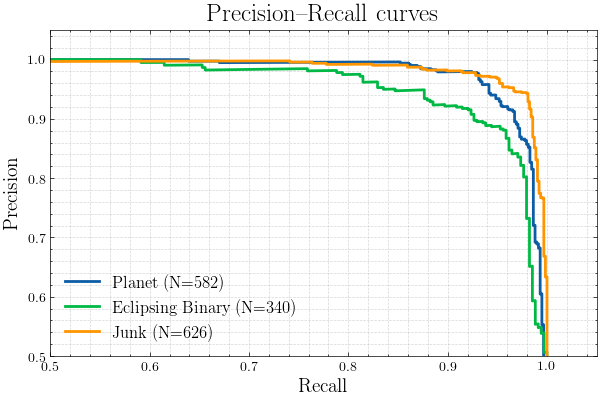

In [9]:

plt.style.use('science')
# If you want widget‐based clicks in a Jupyter environment, uncomment:
# %matplotlib widget

# ─── 0) load & preprocess ────────────────────────────────────────────────
training_run_folder = "/pdo/users/pablomer/mnt/tess/models/vetting/20250502/" \
                      "cshallue/AstroCNNModelVetting_cshallue_20250502_000812"
test_labels = np.load(f"{training_run_folder}/evaluation/test_label.npy")  # (1548,4)
test_pred   = np.load(f"{training_run_folder}/evaluation/test_pred.npy")

# drop the “Not Sure” column
test_labels = np.delete(test_labels, 2, axis=1)
test_pred   = np.delete(test_pred,   2, axis=1)

label_names = ["Planet", "Eclipsing Binary", "Junk"]
counts = test_labels.sum(axis=0).astype(int)

# ─── 1) compute PR for each class ────────────────────────────────────────
pr_data = []
for i in range(len(label_names)):
    y_true  = test_labels[:, i]
    y_score = test_pred[:,   i]
    p, r, t  = precision_recall_curve(y_true, y_score)
    ap       = average_precision_score(y_true, y_score)
    pr_data.append({
        "precision": p,
        "recall":    r,
        "thresholds":t,
        "ap":        ap
    })

# ─── 2) plot all three curves ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)

lines = []
for i, name in enumerate(label_names):
    data = pr_data[i]
    lbl  = f"{name} (N={counts[i]})"
    ln, = ax.plot(data["recall"][:-1],
                  data["precision"][:-1],
                  lw=2, label=lbl)
    lines.append(ln)

ax.set_xlabel("Recall",    fontsize=14)
ax.set_ylabel("Precision", fontsize=14)
ax.set_title("Precision–Recall curves", fontsize=18)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.5, 1.05)

# ─── 3) add interactive annotation ───────────────────────────────────────
annot = ax.annotate(
    "",
    xy=(0,0), xytext=(-40,-20),
    textcoords="offset points",
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.5", fc="w", alpha=0.9, clip_on=False),
    arrowprops=dict(arrowstyle="->")
)
annot.set_visible(False)

def update_annot(class_idx, ind):
    idx = ind["ind"][0]
    d   = pr_data[class_idx]
    annot.xy = (d["recall"][idx], d["precision"][idx])
    annot.set_text(
        f"{label_names[class_idx]}\n"
        f"Precision = {d['precision'][idx]:.3f}\n"
        f"Recall = {d['recall'][idx]:.3f}\n"
        f"Threshold = {d['thresholds'][idx]:.3f}"
    )

def onclick(event):
    if event.inaxes != ax:
        return
    for i, ln in enumerate(lines):
        hit, ind = ln.contains(event)
        if hit:
            update_annot(i, ind)
            annot.set_visible(True)
            fig.canvas.draw_idle()
            return
    # click elsewhere hides the box
    if annot.get_visible():
        annot.set_visible(False)
        fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", onclick)

# ─── 4) legend & show ───────────────────────────────────────────────────
ax.legend(loc="lower left", fontsize=12, framealpha=0.8)
plt.show()

# ─── 5) extra diagnostics (optional) ────────────────────────────────────
# You can still compute confusion matrices, ROC, etc., exactly as before.


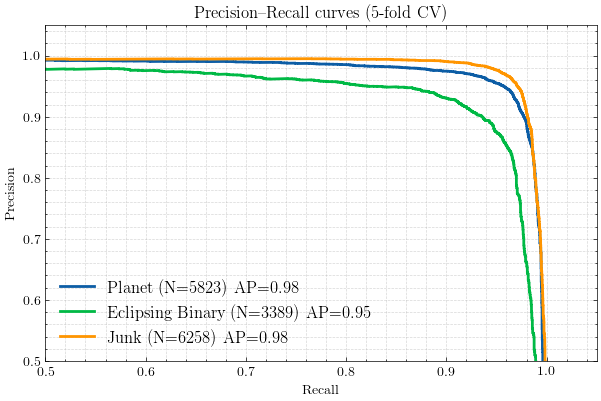

Aggregated exodash table: 15470 rows × 7 cols
   astro_id  model_no    disp_p    disp_e    disp_n    disp_j true_label
0      3083         1  0.066332  0.917412  0.001362  0.014894          e
1      3089         1  0.923843  0.051268  0.000977  0.023912          p
2      3109         1  0.003905  0.890300  0.001592  0.104203          e
3      3112         1  0.002862  0.908750  0.001347  0.087041          e
4      3113         1  0.013304  0.975606  0.001075  0.010015          e


In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
)
# import scienceplots
# plt.style.use('science')
# %matplotlib widget   # if you want interactive

# ─── 0) locate & load all folds ────────────────────────────────────────────
cv_root   = "/pdo/users/pablomer/mnt/tess/models/vetting/20250522-1615/pablomer-cv"
fold_dirs = sorted(glob.glob(os.path.join(cv_root, "fold*")))

labels_list = []
preds_list  = []
csv_list    = []    # ← collect each fold's exodash CSV

for fold in fold_dirs:
    # ─── find the evaluation/ dir ─────────────────────────────────────────
    eval_dirs = glob.glob(os.path.join(fold, "**", "evaluation"), recursive=True)
    if not eval_dirs:
        raise RuntimeError(f"no evaluation dir found under {fold!r}")
    eval_dir = eval_dirs[0]

    # ─── load val labels & preds ───────────────────────────────────────────
    lab  = np.load(os.path.join(eval_dir, "val_label.npy"))
    pred = np.load(os.path.join(eval_dir, "val_pred.npy"))
    labels_list.append(lab)
    preds_list.append(pred)

    # ─── find & read that fold’s exodash CSV ───────────────────────────────
    csv_paths = glob.glob(os.path.join(fold, "**", "val_exodash_results.csv"), recursive=True)
    if not csv_paths:
        raise RuntimeError(f"no val_exodash_results.csv found under {fold!r}")
    csv_path = csv_paths[0]
    df      = pd.read_csv(csv_path)
    csv_list.append(df)

# ─── aggregate everything ─────────────────────────────────────────────────
# stack labels & preds
all_labels = np.vstack(labels_list)
all_preds  = np.vstack(preds_list)

# drop the “Not Sure” column (index 2)
all_labels = np.delete(all_labels, 2, axis=1)
all_preds  = np.delete(all_preds,  2, axis=1)

# stack CSVs
all_exodash = pd.concat(csv_list, ignore_index=True)

# ─── now do your PR-curve plotting exactly as before ─────────────────────
label_names = ["Planet", "Eclipsing Binary", "Junk"]
counts = all_labels.sum(axis=0).astype(int)

pr_data = []
for i, name in enumerate(label_names):
    y_true  = all_labels[:, i]
    y_score = all_preds[:,  i]
    p, r, t = precision_recall_curve(y_true, y_score)
    ap      = average_precision_score(y_true, y_score)
    pr_data.append(dict(precision=p, recall=r, thresholds=t, ap=ap))

fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)
for i, name in enumerate(label_names):
    d   = pr_data[i]
    lbl = f"{name} (N={counts[i]})  AP={d['ap']:.2f}"
    ax.plot(d["recall"][:-1], d["precision"][:-1], lw=2, label=lbl)

ax.set(xlabel="Recall", ylabel="Precision",
       title="Precision–Recall curves (5-fold CV)")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.5, 1.05)
ax.legend(loc="lower left", fontsize=12, framealpha=0.8)

plt.show()

# ─── finally, if you want to inspect the combined exodash results: ───────
print(f"Aggregated exodash table: {all_exodash.shape[0]} rows × {all_exodash.shape[1]} cols")
# e.g. display first few rows
print(all_exodash.head())

# Save the csv
all_exodash.to_csv("exodash_5folds.csv", index=False)


In [8]:
import os
os.getcwd()

'/pdo/users/pablomer'